<hr/>

# [Generalized Linear Mixed Models](https://donnievin.github.io/ASDA_2/)
By: **Donovan Vincent Jr** - dvincen9@jh.edu <br/>
Adapted From: **Dr. Sergey Kushnarev's ASDA II** <br/>
Estimated Workthrough Time: **90 mins**

<hr/>

<h1><font color="blue">Fitting GLM and Inference</font></h1>

Topics: 
* Fisher Scoring vs Newton Raptison
* Model / Variable Selection
* Measuring Predictive Power: LL, AIC, BIC
* Effects of Collinearity (Ill-conditioned)
* Example 1: Satellite Crabs
* Example 2: Florida House Prices

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
import statsmodels.api as sm # https://www.statsmodels.org/stable/datasets/index.html
import statsmodels.formula.api as smf

# <font color='lightblue'> Fisher Scoring vs Newton Raptison </font>

> Fitting of a GLM 

We fit a Generalized Linear Model by finding the parameter vector, $\hat{\beta}$, that maximizes the log likelihood. This can be achieved numerically via the goal: 
<div align="center">

$$
\hat{\beta} = \argmax_{\beta} \mathcal{L} (\beta)
$$

</div>


--- 

> Fisher Scoring

Uses Fisher Information Matrix

___ 

> Newton Raptison

Uses Hessian of Log-likelihood 


--- 

<font color='purple'> Note, for the Canonical Link function, the Newton Raptison and Fisher Scoring approximations are the same


# <font color='lightblue'> Model / Variable Selection </font>

> Goal 

Given predictors $X \in \{x_1, x_2, ... , x_p \}$, we want to know which predictors are <font color='red'>useful</font> for the model


--- 

> Forward Selection


--- 

> Backwards Elimination (preferred)

Data is expensive, want to use as many predictors as you can. 


--- 

> Things to keep in mind

* If interaction is added, the main effects MUST be added as well, even if they are not significant
* If 1 level of qualitative predictors is added / removed, all others of the same predictors need to be added / removed

<div align="center">

$$
log(\mu_i) = \beta_0
$$

</div>

<font color='purple'> Note, we need to exponentiate the fitted parameter to get back the mean! </font>

In [ ]:
np.random.seed(31100)

n = 40
X = np.random.normal(size=n) # Design matrix (nx1)

beta0, beta1 = 1, 0.5 # Parameter vector we are trying to recover with GLM

# Calculate mu_i using the link function g(mu_i) = beta0 + beta1 * X1, then generate Y_is ~ Pois(mu_i)
mu_i = np.exp(beta0 + beta1*X) # 
Y = np.random.poisson(lam=mu_i)

plt.scatter(X, Y)
plt.title("Scatter plot of Synthetic Poisson Data")
plt.xlabel("X")
plt.ylabel(r"$Y \sim Poisson(\mu_i)$")
plt.show()

# Put into a pandas DataFrame (needed for formula API)
Synthetic_df = pd.DataFrame({
    "Y": Y,
    "X": X,
})

intercept_only_fit = smf.glm(
    formula = "Y~1",
    data = Synthetic_df,
    family = sm.families.Poisson()
).fit()

print(intercept_only_fit.summary())

# Need to clean up or else it will be a zig-zag function
df_sorted = Synthetic_df.sort_values("X") 
Y_predicted_null = intercept_only_fit.predict(df_sorted) # Does the exponentiation for us!

plt.scatter(X, Y, label=r'Observed Data ($Y_i$)')
plt.plot(df_sorted["X"], Y_predicted_null, color='red', label=r'Fitted Mean ($\hat{\mu_i}$)')
plt.legend()
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   40
Model:                            GLM   Df Residuals:                       39
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -84.036
Date:                Sun, 03 May 2026   Deviance:                       58.522
Time:                        19:49:38   Pearson chi2:                     47.2
No. Iterations:                     4   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1787      0.088     13.439      0.0

# <font color='lightblue'> Measuring Predictive Power </font>

> Remember R^2 from LMs


---

> Correlation

We don't have SSR/SSTo, but we can still calculate corr(y, mu^hat)

--- 

> Log-likelihood 

It is the proportion of log-likelihoods explained by the model. Define the following terms: 

* $\mathcal{L}_0$: null / intercept only model (smallest possible log-likelihood)
* $\mathcal{L}_m$: current model (obtained from maximization objective above)
* $\mathcal{L}_{sat}$: saturated / full parameter model (largest possible log-likelihood)

<div align="center">

$$
\Lambda = \frac{\mathcal{L}_m - \mathcal{L}_0}{\mathcal{L}_{sat} -\mathcal{L}_0}
$$

</div>


--- 

> Akaike Information Criteria (AIC)

Find the model closest to the true model, measured via distance in probability distribution space (we want to minimize)


<div align="center">

$$
AIC = -2[\mathcal{L}( \hat{\beta_{MLE}} - N_{params})]
$$

</div>

--- 

> Bayesian Information Criteria (AIC)

Find the model closest to the true model, measured via distance in probability distribution space (we want to minimize)


<div align="center">

$$
BIC = -2[\mathcal{L}( \hat{\beta_{MLE}} - log(N)N_{params})]
$$

</div>

<font color='purple'> Note, BIC chooses smaller models than BIC </font>

In [35]:
Poisson_GLM_fit = smf.glm(
    formula="Y~X",
    data = Synthetic_df,
    family = sm.families.Poisson()
).fit()

print(Poisson_GLM_fit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   40
Model:                            GLM   Df Residuals:                       38
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -75.826
Date:                Sun, 03 May 2026   Deviance:                       42.100
Time:                        20:21:05   Pearson chi2:                     31.6
No. Iterations:                     4   Pseudo R-squ. (CS):             0.3367
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1383      0.091     12.450      0.0

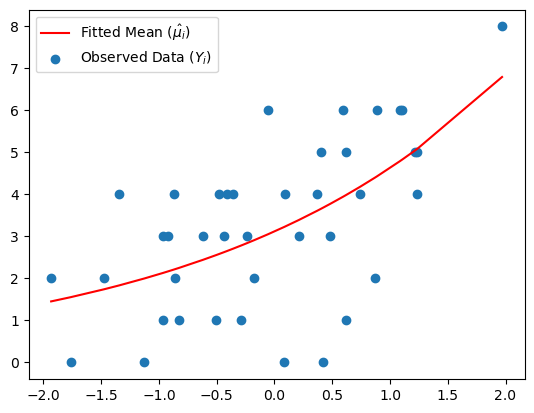

In [ ]:
Y_predicted_GLM = Poisson_GLM_fit.predict(df_sorted) # Does the exponentiation for us!

plt.scatter(X, Y, label=r'Observed Data ($Y_i$)')
plt.plot(df_sorted["X"], Y_predicted_GLM, color='red', label=r'Fitted Mean ($\hat{\mu_i}$)')
plt.legend()
plt.show()

# <font color='lightblue'> Effects of Collinearity </font>

> Methods to detect collinearity
1. Pairwise Correlations 
2. Variance Inflation Factors (VIF)

---

> 

## Visualizing both fits

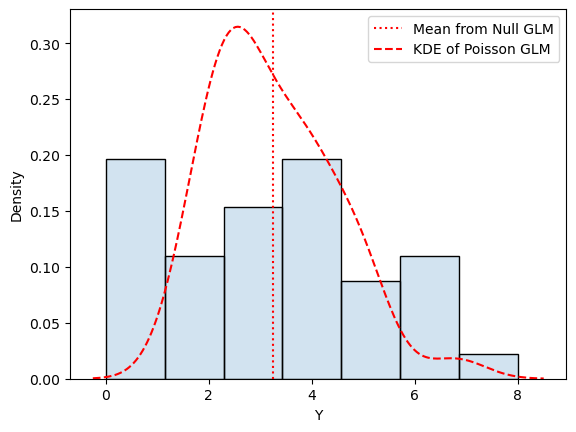

In [69]:
sns.histplot(data=Synthetic_df, x="Y", stat="density", alpha=0.2)
plt.axvline(Y_predicted_null[0], color='red', linestyle=':', label='Mean from Null GLM') # Null model has 0 variance, so can't do a KDE estimation
sns.kdeplot(Y_predicted_GLM, color='red', linestyle='--', label='KDE of Poisson GLM')
plt.legend()
plt.show()

## Degrees of Freedom

In [76]:
print(f'Total Number of Data Points: {n}')
print(f'Degrees of Freedom from Null Model: {intercept_only_fit.df_resid}') # df = N - p
print(f'Degrees of Freedom from Poisson GLM: {Poisson_GLM_fit.df_resid}')

Total Number of Data Points: 40
Degrees of Freedom from Null Model: 39
Degrees of Freedom from Poisson GLM: 38


In [75]:
print(intercept_only_fit.df_model)   # model degrees of freedom --> independent predictors you’re estimating (excluding the intercept)
print(intercept_only_fit.df_resid)   # residual degrees of freedom --> N - p

print(Poisson_GLM_fit.df_model)   # model degrees of freedom --> independent predictors you’re estimating (excluding the intercept)
print(Poisson_GLM_fit.df_resid)   # residual degrees of freedom --> N - p

0
39
1
38


## Deviance

In [74]:
print(f'Total Number of Data Points: {n}')
print(f'Degrees of Freedom from Null Model: {intercept_only_fit.deviance}') # df = N - p
print(f'Degrees of Freedom from Poisson GLM: {Poisson_GLM_fit.deviance}')

Total Number of Data Points: 40
Degrees of Freedom from Null Model: 58.52170400498834
Degrees of Freedom from Poisson GLM: 42.10028234116814


In [ ]:
# Note null deviance = deviance from null (intercept only) model ; residual deviance = deviance from fitted model
print("Residual deviance (Default):", intercept_only_fit.deviance) # N degrees of freedom = n - (#params)
print("Null deviance:", intercept_only_fit.null_deviance) # N degrees of freedom = n - (#params) = n - 1 (ALWAYS)

# <font color='lightblue'> Example 1: Satellite Crabs </font>

> Problem Set Up

In


In [4]:
crabs_url = 'https://alanagresti.com/glm/data/Crabs.dat'
crab_df = pd.read_csv(crabs_url, delim_whitespace=True)

print(crab_df)

     crab  y  weight  width  color  spine
0       1  8   3.050   28.3      2      3
1       2  0   1.550   22.5      3      3
2       3  9   2.300   26.0      1      1
3       4  0   2.100   24.8      3      3
4       5  4   2.600   26.0      3      3
..    ... ..     ...    ...    ...    ...
168   169  3   2.750   26.1      3      3
169   170  4   3.275   29.0      3      3
170   171  0   2.625   28.0      1      1
171   172  0   2.625   27.0      4      3
172   173  0   2.000   24.5      2      2

[173 rows x 6 columns]


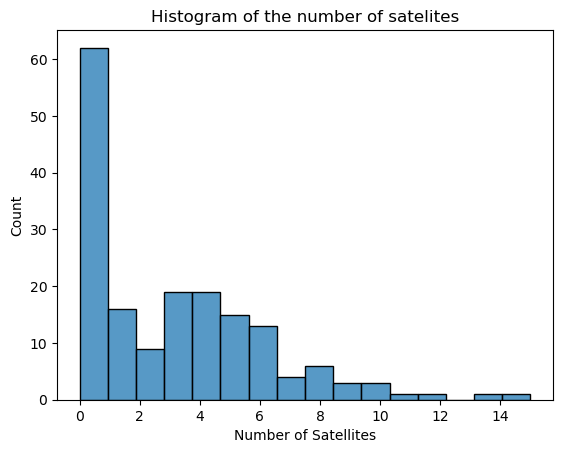

In [12]:
sns.histplot(data=crab_df, x='y', bins=16)
plt.xlabel('Number of Satellites')
plt.title('Histogram of the number of satelites')
plt.show()

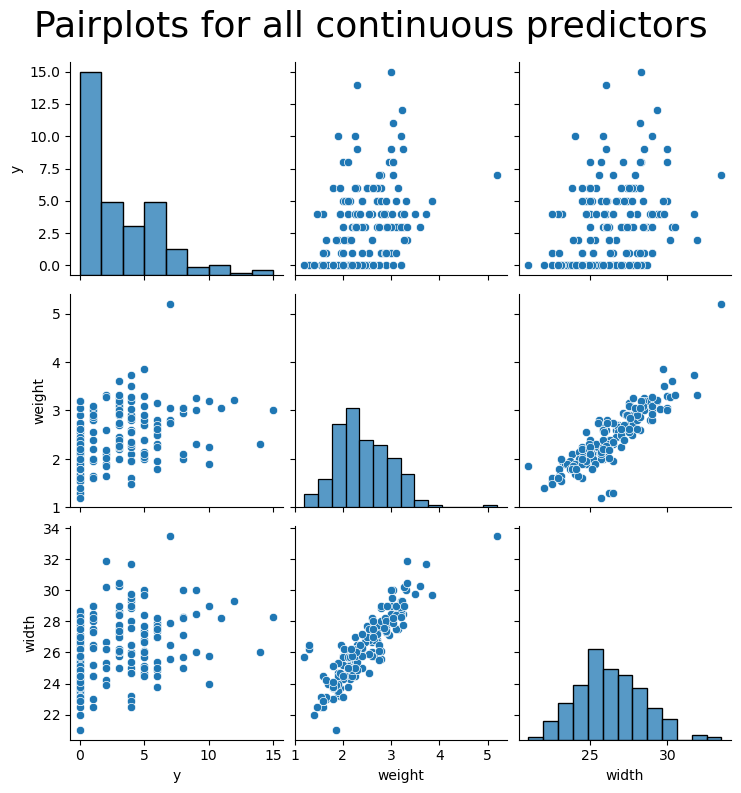

In [19]:
# Quantitative predictors = scatter plots
g = sns.pairplot(crab_df[['y', 'weight', 'width']])
g.fig.suptitle('Pairplots for all continuous predictors', y=1.05, fontsize=26)
plt.show()

Text(0.5, 1.0, 'Width')

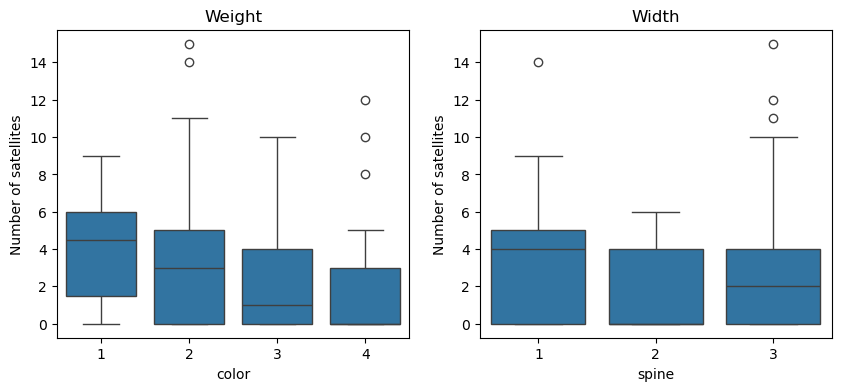

In [11]:
# Qualitative predictors = box plots
fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.boxplot(data=crab_df, y='y', x='color', ax=axes[0])
axes[0].set_ylabel("Number of satellites")
axes[0].set_title("Weight")

sns.boxplot(data=crab_df, y='y', x='spine', ax=axes[1])
axes[1].set_ylabel("Number of satellites")
axes[1].set_title("Width")

In [21]:
width_weight_model = smf.glm(
    formula="y~width + weight", 
    data=crab_df, 
    family=sm.families.Poisson()
).fit()

print(width_weight_model.summary())


# This tells us: log(ui(hat)) = -1.3 + 0.05Wi + 0.45We (Note: Width LOST significant --> Collinearity)
#print(f'Pearson correlation btwn Width and Weight: r = {crab_df['width'].corr(crab_df['weight'])}')

# Notice the std error is nearly double... VIF = 1 / (1-R^2) --> VAR(2) = VIF VAR(1) --> SE(2) = SQRT(VIF) SE(1)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  173
Model:                            GLM   Df Residuals:                      170
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -457.60
Date:                Mon, 04 May 2026   Deviance:                       559.90
Time:                        18:15:00   Pearson chi2:                     537.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3438
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2952      0.899     -1.441      0.1

# <font color='lightblue'> Example 2: Florida House Prices </font>

> Connections

In 


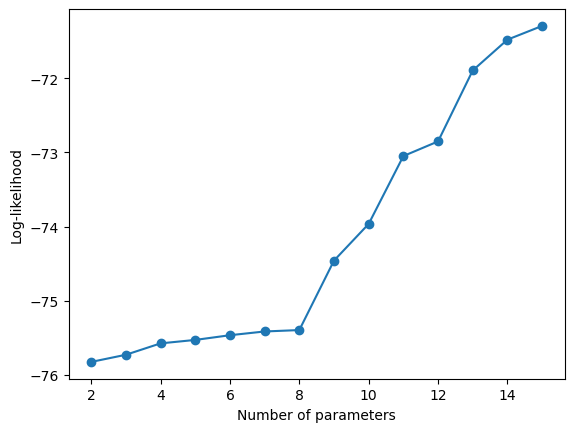

In [86]:
max_p = 14  # max polynomial degree
log_likelihoods = []
n_params = []

for p in range(1, max_p + 1):
    # build formula like: Y ~ X + X^2 + X^3 ...
    terms = " + ".join([f"np.power(X, {i})" for i in range(1, p + 1)])
    formula = "Y ~ " + terms

    model = smf.glm(formula=formula, data=Synthetic_df,
                    family=sm.families.Poisson()).fit()

    log_likelihoods.append(model.llf)
    n_params.append(model.df_model + 1)  # +1 for intercept

plt.plot(n_params, log_likelihoods, marker='o')
plt.xlabel("Number of parameters")
plt.ylabel("Log-likelihood")
plt.show()

# Further References

1. [Chapter 4:](https://download.e-bookshelf.de/download/0003/0821/70/L-G-0003082170-0005968026.pdf) Foundations of Linear and Generalized Linear Models
2. ???